In [31]:
import os
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, f1_score
from collections import Counter

In [32]:
df = pd.read_csv('image_metadata.csv')
df

,file_path,experiment_id,position,trap_num,sample_id,treated,timepoint,species_label
0,C:\Users\silve\Documents\210\data\Cropped-png-...,BV6126 AST FISH 201116,101,16,43-16,Untreated,0,P. aeruginosa
1,C:\Users\silve\Documents\210\data\Cropped-png-...,BV6126 AST FISH 201116,101,16,43-16,Untreated,1,P. aeruginosa
2,C:\Users\silve\Documents\210\data\Cropped-png-...,BV6126 AST FISH 201116,101,16,43-16,Untreated,2,P. aeruginosa
3,C:\Users\silve\Documents\210\data\Cropped-png-...,BV6126 AST FISH 201116,101,16,43-16,Untreated,3,P. aeruginosa
4,C:\Users\silve\Documents\210\data\Cropped-png-...,BV6126 AST FISH 201116,101,16,43-16,Untreated,4,P. aeruginosa
...,...,...,...,...,...,...,...,...
106838,C:\Users\silve\Documents\210\data\Cropped-png-...,BV6134 AST FISH 201126,281,20,3408-03,Treated,25,E. coli
106839,C:\Users\silve\Documents\210\data\Cropped-png-...,BV6134 AST FISH 201126,281,20,3408-03,Treated,26,E. coli
106840,C:\Users\silve\Documents\210\data\Cropped-png-...,BV6134 AST FISH 201126,281,20,3408-03,Treated,27,E. coli
106841,C:\Users\silve\Documents\210\data\Cropped-png-...,BV6134 AST FISH 201126,281,20,3408-03,Treated,28,E. coli


In [33]:
def load_image(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    image = cv2.resize(image, (128, 128))
    return image

# Extracts HOG, Canny, and Contour features
def extract_features(image):
    # HOG Features
    hog_features, _ = hog(image, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=True)
    
    # Canny Edge Features
    edges = cv2.Canny(image, 100, 200)
    edge_features = edges.flatten()
    
    # Contour Features
    ret, thresh = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    contour_features = []
    
    max_contours = 5  # Limit to first 5 contours
    for contour in contours[:max_contours]:  
        moments = cv2.moments(contour)
        hu_moments = cv2.HuMoments(moments).flatten()
        contour_features.extend(hu_moments)
    
    # Pad if fewer than max_contours are found
    while len(contour_features) < max_contours * 7:
        contour_features.append(0.0)

    contour_features = np.array(contour_features)
    
    # Combine all features
    features = np.hstack([hog_features, edge_features, contour_features])
    return features

# Function to load dataset
def load_dataset(image_paths, labels):
    X, y = [], []
    for img_path, label in zip(image_paths, labels):
        image = load_image(img_path)
        features = extract_features(image)
        X.append(features)
        y.append(label)
    return np.array(X), np.array(y)

# Extract paths and labels
def get_paths_and_labels(filtered_df_sampled):    
    img_paths, labels = [], []
    for _, row in filtered_df_sampled.iterrows():
        img_paths.append(row['file_path'])  # Image path
        labels.append(row['species_label'])  # Label
    return img_paths, labels

In [34]:
species_map = {'E. faecalis': 0, 'K. pneumoniae': 1, 'E. coli': 2, 'P. aeruginosa': 3}

timepoints = list(range(31))  # Timepoints 0-30
accuracy_scores = []
overall_f1_scores = []
classwise_scores = {species: [] for species in species_map.keys()}
total_images_per_time = []

In [35]:
for t in timepoints:
    print(f"Processing timepoint: {t}")

    # Filter dataset for current timepoint
    filtered_df = df[(df['species_label'] != 'Unknown') & (df['treated'] == 'Untreated') & (df['timepoint'] == t)]
    
    if filtered_df.empty:
        print(f"No images found for timepoint {t}, skipping.")
        accuracy_scores.append(None)
        for species in species_map.keys():
            classwise_scores[species].append(None)
        continue

    img_paths, labels = get_paths_and_labels(filtered_df)
    numerical_labels = [species_map[label] for label in labels]

    # Undersample all classes to the class with the least images
    # (bc model took too long and notebook timed out)
    label_counts = Counter(numerical_labels)
    min_count = min(label_counts.values())
    print(min_count)

    # fixing errors with undersampling
    # Skip timepoint if any class has 0 samples
    if min_count == 0:
        print(f"Skipping timepoint {t} due to missing classes.")
        accuracy_scores.append(None)
        overall_f1_scores.append(None)
        for species in species_map.keys():
            classwise_scores[species].append(None)
        total_images_per_time.append(0)
        continue

    # Require at least 5 images per class before splitting
    if min_count < 5:
        print(f"Skipping timepoint {t} due to insufficient samples (min_count={min_count}).")
        accuracy_scores.append(None)
        overall_f1_scores.append(None)
        for species in species_map.keys():
            classwise_scores[species].append(None)
        total_images_per_time.append(0)
        continue

    # Continue undersample all classes to the min_count
    img_paths_sampled, labels_sampled = [], []
    class_samples = {cls: [] for cls in species_map.values()}

    for img, label in zip(img_paths, numerical_labels):
        class_samples[label].append((img, label))

    for cls in species_map.values():
        sampled_data = class_samples[cls][:min_count]
        for img, label in sampled_data:
            img_paths_sampled.append(img)
            labels_sampled.append(label)

    total_images = len(img_paths_sampled)
    total_images_per_time.append(total_images)
    print(f"Total images used: {total_images}")

    # Load dataset and run classification
    X, y = load_dataset(img_paths_sampled, labels_sampled)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23, stratify=y)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    clf = SVC(kernel='linear')
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    accuracy_scores.append(acc)
    f1_macro = f1_score(y_test, y_pred, average='macro')  
    overall_f1_scores.append(f1_macro)

    class_report = classification_report(y_test, y_pred, output_dict=True)
    for species, class_idx in species_map.items():
        if str(class_idx) in class_report:
            f1_score_class = class_report[str(class_idx)]['f1-score']
            classwise_scores[species].append(f1_score_class)
            print(f"  {species} F1-score: {f1_score_class:.3f}")
        else:
            classwise_scores[species].append(None)

    print(f"Overall Accuracy at {t * 2} min: {acc:.3f}")
    print(f"Overall F1-score at {t * 2} min: {overall_f1:.3f}")

Processing timepoint: 0
250
Total images used: 1000
  E. faecalis F1-score: 0.969
  K. pneumoniae F1-score: 0.961
  E. coli F1-score: 0.911
  P. aeruginosa F1-score: 0.920
Overall Accuracy at 0 min: 0.940
Overall F1-score at 0 min: 0.940
Processing timepoint: 1
250
Total images used: 1000
  E. faecalis F1-score: 0.959
  K. pneumoniae F1-score: 0.961
  E. coli F1-score: 0.929
  P. aeruginosa F1-score: 0.950
Overall Accuracy at 2 min: 0.950
Overall F1-score at 2 min: 0.940
Processing timepoint: 2
250
Total images used: 1000
  E. faecalis F1-score: 0.959
  K. pneumoniae F1-score: 0.980
  E. coli F1-score: 0.928
  P. aeruginosa F1-score: 0.932
Overall Accuracy at 4 min: 0.950
Overall F1-score at 4 min: 0.940
Processing timepoint: 3
250
Total images used: 1000
  E. faecalis F1-score: 0.959
  K. pneumoniae F1-score: 0.970
  E. coli F1-score: 0.940
  P. aeruginosa F1-score: 0.931
Overall Accuracy at 6 min: 0.950
Overall F1-score at 6 min: 0.940
Processing timepoint: 4
250
Total images used: 1

Text(0.5, 1.0, 'Model Performance Over Time')

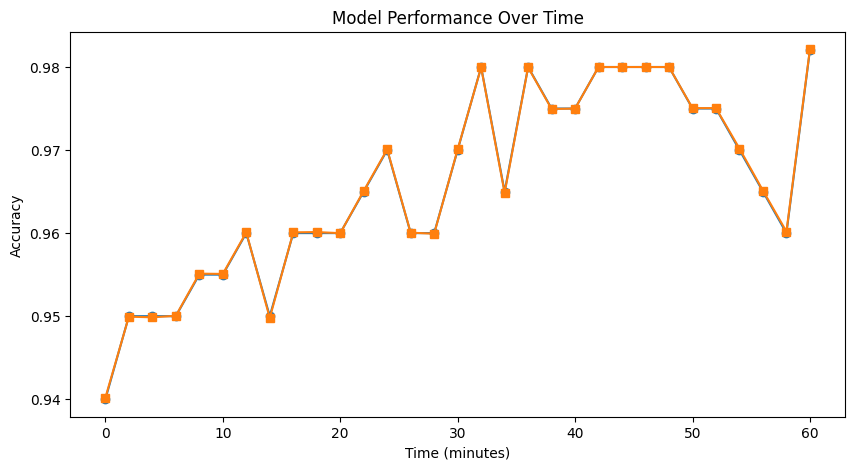

In [38]:
plt.figure(figsize=(10, 5))
plt.plot([t * 2 for t in timepoints], accuracy_scores, marker='o', label="Overall Accuracy")
plt.plot([t * 2 for t in timepoints], overall_f1_scores, marker='s', linestyle='-', label="Overall F1 Score")
plt.xlabel("Time (minutes)")
plt.ylabel("Accuracy")
plt.title("Model Performance Over Time")

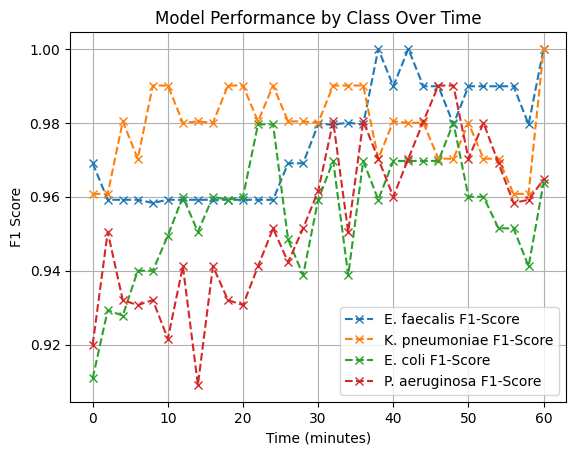

In [39]:
for species, scores in classwise_scores.items():
    plt.plot([t * 2 for t in timepoints], scores, marker='x', linestyle='--', label=f"{species} F1-Score")

plt.xlabel("Time (minutes)")
plt.ylabel("F1 Score")
plt.title("Model Performance by Class Over Time")
plt.legend()
plt.grid()
plt.show()